In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [3]:
from astropy import units as un, constants as cons
import numpy as np
import HaloPotential as Halo
import matplotlib.pyplot as plt
from pathlib import Path
import math, os
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import trapezoid
from scipy.integrate import solve_ivp
import glob,h5py
from scipy.interpolate import RegularGridInterpolator
from get_vc_from_particle import make_vc_interp

ModuleNotFoundError: No module named 'HaloPotential'

In [3]:
plt.rcParams['font.size']=22
plt.rcParams['axes.linewidth']=2
plt.rcParams['xtick.major.size']=10
plt.rcParams['xtick.minor.size']=5
plt.rcParams['xtick.major.width']=2
plt.rcParams['xtick.minor.width']=1
plt.rcParams['xtick.direction']='in'
plt.rcParams['ytick.major.size']=10
plt.rcParams['ytick.minor.size']=5
plt.rcParams['ytick.major.width']=2
plt.rcParams['ytick.minor.width']=1
plt.rcParams['ytick.direction']='in'

In [4]:
cloudy_H_mass_fraction = 1. / (1. + 0.1 * 3.971)
X = cloudy_H_mass_fraction

In [5]:
Msun = 1.988409870698051e+33
G = 6.674299999999999e-08
mp = 1.67262192369e-24
kpc = 3.0856775814913673e+21
gamma = 5./3.
yr_to_sec = 3.154e+7
Myr = yr_to_sec * 1.e6
kmps = 1.e5
kb = 1.38e-16
mu = 0.6
m_H = 1.672623e-24  # g

In [6]:
class Galaxy:
    def __init__(self, galtype):
        self.galtype = galtype.upper()

        if self.galtype == "LMC":
            self.Mvir = 1.775e11 * cons.M_sun   # LMC mass from Shah+
            self.potential = Halo.NFW(Mvir=self.Mvir, z=0, cvir=10)
            self.Z2Zsun = 0.5
            self.Rvir  = self.potential.rvir().value
            self.Thalo = 3.e6

        elif self.galtype == "MW":
            self.Mvir = 1.074e12 * cons.M_sun   # MW mass (AGORA)
            self.potential = Halo.NFW(Mvir=self.Mvir, z=0, cvir=10)
            self.Z2Zsun = 1.0
            self.Rvir  = self.potential.rvir().value
            self.Thalo = 1.e6
            

        else:
            raise ValueError(f"Unknown galaxy type: {galtype}. Use 'LMC' or 'MW'.")

        # Derived quantities
        self.rvir = self.potential.rvir()
        self.vc200 = self.potential.vc(self.rvir)


In [7]:
gal = Galaxy("LMC")
Mvir = gal.Mvir
potential = gal.potential
Z2Zsun = gal.Z2Zsun
rvir = gal.Rvir
Thalo = gal.Thalo
rvir, Thalo

(np.float64(148.2286124193434), 3000000.0)

In [8]:
from scipy.integrate import cumulative_trapezoid
r1 = np.linspace(0.1,rvir,1000)
g = potential.g(r1*un.kpc).cgs.value
integrand = -(g * mu * m_H * kpc / kb / Thalo)
I = cumulative_trapezoid(integrand, r1, initial=0.0)
nH_scal = np.exp(I)
rho_scal = nH_scal * m_H/X
A = 0.12 * Mvir.cgs.value/(trapezoid(4.*math.pi*r1*r1*rho_scal, r1) * kpc**3)
rho_profile = A*rho_scal
nH = A * nH_scal
total_mass = trapezoid(4.*math.pi*r1*r1*rho_profile, r1) * kpc**3
total_mass, 0.12 * Mvir.cgs.value, A

(np.float64(4.2353130245868484e+43),
 np.float64(4.235313024586849e+43),
 np.float64(8.124199223730866e-05))

Plot nH

Text(0.5, 0, '$r$ [kpc]')

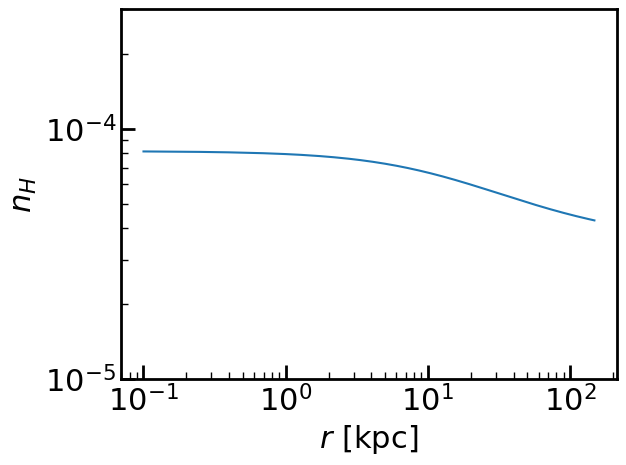

In [9]:
plt.plot(r1, nH)
plt.ylim(1.e-5, 3.e-4)
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'$n_H$')
plt.xlabel(r'$r$ [kpc]')

Plot vc

Text(0.5, 0, '$r$ [kpc]')

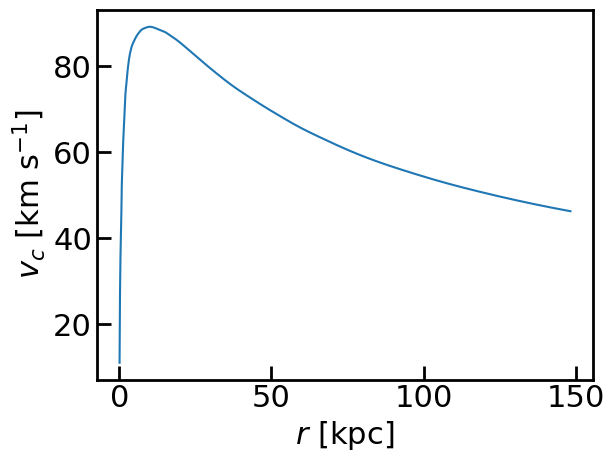

In [10]:
path_to_particle_file = '/Users/aditivijayan/quokka/INCITE/dwGal_setup/GalIC'
file_name = 'LMC_1000sol.txt'
infile = os.path.join(path_to_particle_file, file_name)

log_vc_interp = make_vc_interp(infile)
vc = 10.**log_vc_interp(np.log10(r1*kpc))
plt.plot(r1, vc)
plt.ylabel(r'$v_c$ [km s$^{-1}$]')
plt.xlabel(r'$r$ [kpc]')

In [11]:
filename = "dwarf_halo_IC_hse.csv"

# --- Inputs ---
r = r1             # kpc        
rho_profile = rho_profile # density
v = np.full(rho_profile.shape, 0.0)              # km/s

T = np.full(rho_profile.shape, Thalo) 

# --- Dimensions ---
Ndim = 1
Nx = [len(r)]
Nout = 4

input_names = ["R"]
output_names = ["vcirc", "rho", "velr", "T"]

input_units = ["kpc"]
output_units = ["kms", "cgs", "cgs", "K"]

xlo = [r.min()]
xhi = [r.max()]

spacing = ["linear"]

# --- Stack output data ---
# Shape: (Nr, Nout)
data = np.vstack([vc, rho_profile, v, T])

# --- Write CSV ---
with open(filename, "w") as f:
    # Line 1–10: metadata
    f.write(f"{Ndim}\n")
    f.write(",".join(map(str, Nx)) + "\n")
    f.write(f"{Nout}\n")
    f.write(",".join(input_names) + "\n")
    f.write(",".join(output_names) + "\n")
    f.write(",".join(input_units) + "\n")
    f.write(",".join(output_units) + "\n")
    f.write(",".join(f"{val:.17e}" for val in xlo) + "\n")
    f.write(",".join(f"{val:.17e}" for val in xhi) + "\n")
    f.write(",".join(spacing) + "\n")

    for row in data:
        f.write(",".join(f"{val:.17e}" for val in row) + "\n")

print(f"Wrote CSV table to {filename}")


Wrote CSV table to dwarf_halo_IC_hse.csv


In [12]:
shield = False
if shield:
    table = 'CloudyData_UVB=HM2012_shielded.h5'
else:
    table = 'CloudyData_UVB=HM2012.h5'
filename = Path.cwd() / table

In [13]:
Z = 0.02  # metal fraction by mass
Y = 1. - X - Z
mean_metals_A = 16.  # mean atomic weight of metals
sigma_T = 6.6524e-25  
electron_mass_cgs = 9.1093897e-28  # electron mass (g)
mu = 0.6
m_H = 1.672623e-24  # g
T_cmb = 2.725  # * (1 + z); // K
c_light_cgs_ = 2.99792458e10  # cgs
radiation_constant_cgs_ = 7.5646e-15  # cgs
boltzmann_constant_cgs_ = 1.380658e-16  # cgs

In [14]:
with h5py.File(filename, "r") as f:
    metal_cooling = f["CoolingRates/Metals/Cooling"][:,0,:]
    metal_heating = f["CoolingRates/Metals/Heating"][:,0,:]
    primordial_cooling = f["CoolingRates/Primordial/Cooling"][:,0,:]
    primordial_heating = f["CoolingRates/Primordial/Heating"][:,0,:]
    lognHbins = f['CoolingRates/Metals/Cooling'].attrs['Parameter1']
    Tbins = f['CoolingRates/Metals/Cooling'].attrs['Temperature']

nHgrid,  Tgrid = np.meshgrid(10.** lognHbins, Tbins, indexing='ij')
nHbins = 10.**lognHbins

net_metalprim_heating_rate = nHgrid **2 *  (Z2Zsun*(metal_heating - metal_cooling) + (primordial_heating - primordial_cooling))

rhoHgrid = nHgrid* m_H
rho = rhoHgrid / cloudy_H_mass_fraction


#Photoelectric heating Rate
n_e = (rho / m_H) * \
                 (1.0 - mu * (X + Y / 4. + Z / mean_metals_A)) / \
                 (mu - ( electron_mass_cgs / m_H))

Tsqrt = np.sqrt(Tgrid)
phi = 0.5 
G_0 = 1.7  
epsilon = \
4.9e-2 / (1. + 4.0e-3 * (G_0 * Tsqrt / (n_e * phi))**0.73) + \
3.7e-2 * (Tgrid / 1.0e4)**(0.7) / \
    (1. + 2.0e-4 * (G_0 * Tsqrt / (n_e * phi)))
Gamma_pe = 1.3e-24 * nHgrid * epsilon * G_0
heating_rate_PE = 1. * (Z2Zsun * Gamma_pe)  

#Compton Cooling
E_cmb = radiation_constant_cgs_ * (T_cmb * T_cmb * T_cmb * T_cmb)
Gamma_C = (8. * sigma_T * E_cmb) / (3. * cons.m_e.value * c_light_cgs_)
C_n     = Gamma_C * boltzmann_constant_cgs_ / (5. / 3. - 1.0)
compton_CMB = - (C_n * (Tgrid - T_cmb) * n_e)  

net_edot_heating_min_cooling = (net_metalprim_heating_rate + heating_rate_PE + compton_CMB)
net_edot_cooling = -net_edot_heating_min_cooling

In [15]:
interp_edot = RegularGridInterpolator((lognHbins, np.log10(Tbins)), net_edot_cooling)

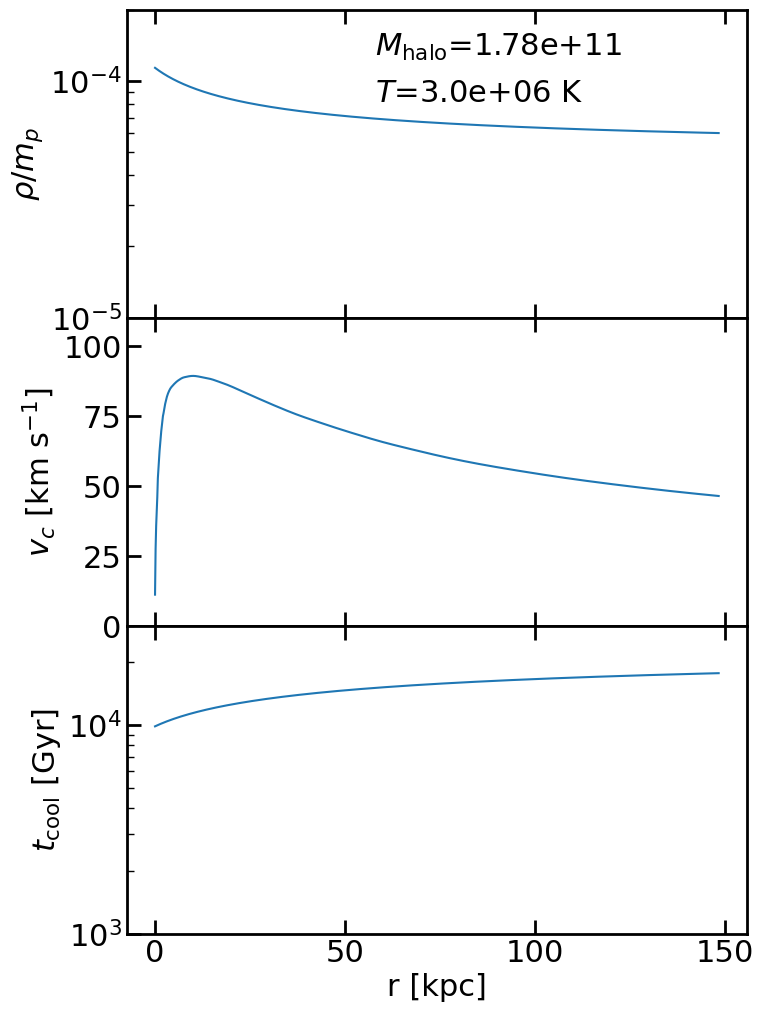

In [16]:
rkpc = r1

edot = interp_edot((np.log10(nH), np.log10(Thalo)))
coolingtime = 1.5 * boltzmann_constant_cgs_ * Thalo/edot

fig, ax = plt.subplots(3, 1, gridspec_kw = {'wspace':0.1, 'hspace':0.0},figsize=(8, 12))

ylabel = [r'$\rho/m_p$', r'$v_c$ [km s$^{-1}$]', r'$t_{\rm cool}$ [Gyr]']

ax[0].plot(rkpc, rho_profile/m_H)
ax[1].plot(rkpc, vc)
ax[2].plot(rkpc, coolingtime/Myr/1.e3)

ax[-1].set_xlabel('r [kpc]')
for i in range(3):
    ax[i].set_ylabel(ylabel[i])
# plt.setp(ax, 'xscale', ('log'))
plt.setp(ax[0], 'yscale', ('log'))
plt.setp(ax[2], 'yscale', ('log'))
# plt.setp(ax, 'xlim', (0.001,20.))
ax[0].set_ylim(1.e-5, 2.e-4)
ax[1].set_ylim(0.0, 110)
ax[2].set_ylim(1.e3, 3.e4)

ax[0].tick_params(axis='x', which='both', labelbottom=False, top=True, bottom=True)
ax[1].tick_params(axis='x', which='both', labelbottom=False, top=True, bottom=True)
ax[2].tick_params(axis='x', which='both', labelbottom=True, top=True, bottom=True)
ax[0].text(0.4, 0.85, r'$M_{\rm halo}$=%.2e'%(Mvir.cgs.value/Msun), transform=ax[0].transAxes)
ax[0].text(0.4, 0.7, r'$T$=%.1e'%(Thalo) + ' K', transform=ax[0].transAxes)

image_name = 'solution_isothermal_' + '%.2e'%(Thalo) +'.jpeg'
plt.savefig(image_name, bbox_inches='tight')